In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

In [2]:
def load_and_prepare_mnist(csv_file):

    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values

    # Normalize pixel values
    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()

X = digits.data
y = digits.target

# normalize
X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

In [8]:
def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [9]:
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b

    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [10]:
def loss_softmax(y_pred, y):

    loss = -np.sum(y * np.log(y_pred + 1e-9)) / y.shape[0]

    return loss

In [11]:
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred + 1e-9))

    return total_loss / n

In [12]:
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n

    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [13]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)

        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print("Iteration", i, "Cost:", cost)

    return W, b, cost_history

In [14]:
d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

In [15]:
alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train,
    y_train,
    W,
    b,
    alpha,
    n_iter,
    show_cost=True
)

Iteration 0 Cost: 2.281824519525282
Iteration 100 Cost: 1.1173982658802792
Iteration 200 Cost: 0.7335998742269279
Iteration 300 Cost: 0.5652396293993418
Iteration 400 Cost: 0.4718097517426576
Iteration 500 Cost: 0.4119498276307165
Iteration 600 Cost: 0.36992404005147195
Iteration 700 Cost: 0.3385343247785203
Iteration 800 Cost: 0.3140297458455794
Iteration 900 Cost: 0.2942599121733311


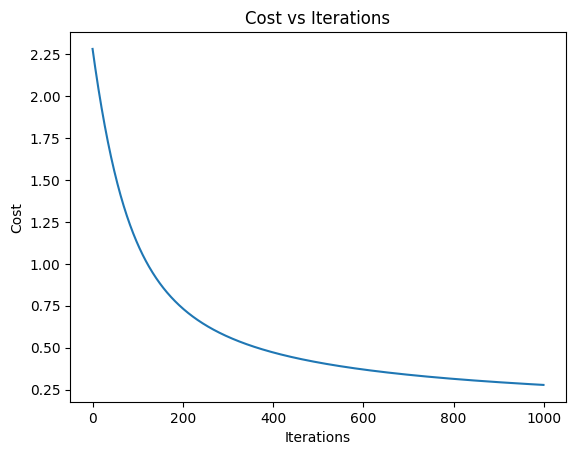

In [16]:
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [17]:
y_pred = predict_softmax(X_test, W_opt, b_opt)

y_test_labels = np.argmax(y_test, axis=1)

In [18]:
cm = confusion_matrix(y_test_labels, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 25  1  0  0  0  0  0  0  2]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 32  0  0  0  0  2  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 42  1  0  0  4]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  1  0  0  0  1  0  1  1 36]]


In [19]:
precision = precision_score(y_test_labels, y_pred, average="weighted")
recall = recall_score(y_test_labels, y_pred, average="weighted")
f1 = f1_score(y_test_labels, y_pred, average="weighted")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9459687861682059
Recall: 0.9444444444444444
F1 Score: 0.9447887275317972


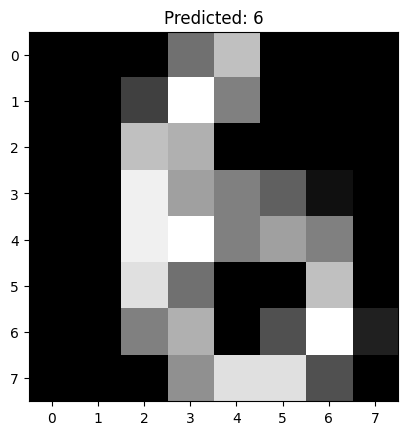

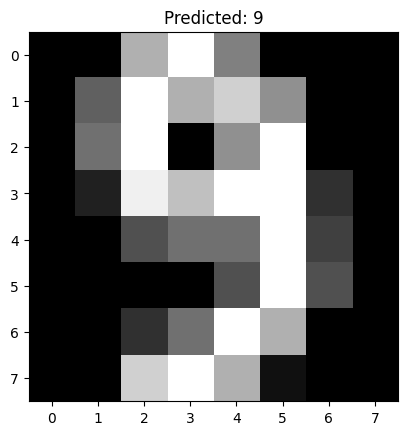

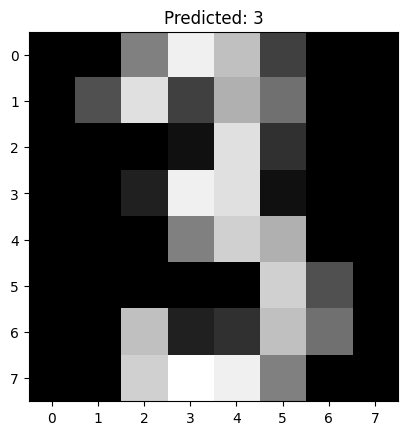

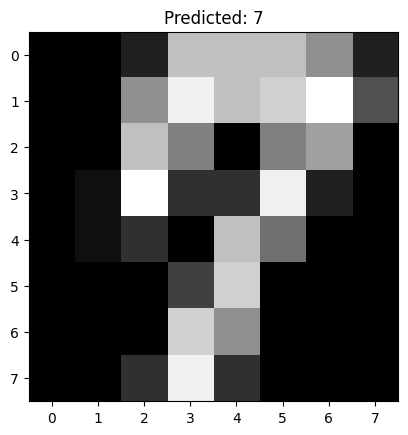

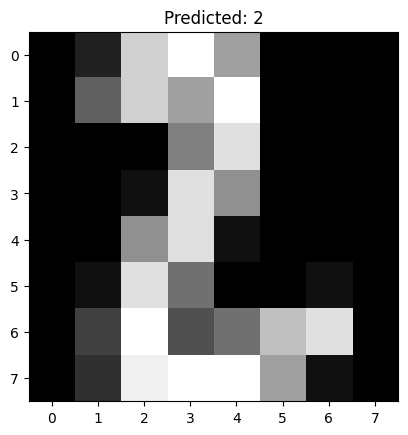

In [21]:
for i in range(5):

    image = X_test[i].reshape(8,8)

    plt.imshow(image, cmap="gray")

    plt.title("Predicted: " + str(y_pred[i]))

    plt.show()